파머완 4.9 분류 실습 - 캐글 산탄데르 고객 만족 예측

데이터 전처리

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pit
import matplotlib
import warnings

warnings.filterwarnings('ignore')
cust_df = pd.read_csv("./train_santander.csv", encoding='latin-1')
print('dataset shape：',cust_df.shape)
cust_df.head(3)

dataset shape： (76020, 371)


,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.17,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.03,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.77,0


In [9]:
cust_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76020 entries, 0 to 76019
Columns: 371 entries, ID to TARGET
dtypes: float64(111), int64(260)
memory usage: 215.2 MB


In [10]:
# Null 값은 없다. 전체 데이터에서 만족과 불만족의 비율 살피기

print(cust_df['TARGET'].value_counts())
unsatisfied_cnt=cust_df[cust_df['TARGET']==1].TARGET.count()
total_cnt=cust_df.TARGET.count()
print('unsatisfied 비율은 {0:.2f}'.format((unsatisfied_cnt/total_cnt)))

TARGET
0    73012
1     3008
Name: count, dtype: int64
unsatisfied 비율은 0.04


value_counts( ) : 판다스에서 어떤 종류의 값이 몇 개씩 있는지 세어주는 함수

-> 전체 개수가 76020인데, 0(=불만족)과 1을 합쳤을 때 76020이므로 Null이 없다. 

In [11]:
# describe( ) 메서드를 이용해 각 피처의 값 분포 확인

cust_df.describe()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
count,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,...,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,7.602000e+04,76020.000000
mean,75964.050723,-1523.199277,33.212865,86.208265,72.363067,119.529632,3.559130,6.472698,0.412946,0.567352,...,7.935824,1.365146,12.215580,8.784074,31.505324,1.858575,76.026165,56.614351,1.172358e+05,0.039569
std,43781.947379,39033.462364,12.956486,1614.757313,339.315831,546.266294,93.155749,153.737066,30.604864,36.513513,...,455.887218,113.959637,783.207399,538.439211,2013.125393,147.786584,4040.337842,2852.579397,1.826646e+05,0.194945
min,1.000000,-999999.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.163750e+03,0.000000
25%,38104.750000,2.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.787061e+04,0.000000
50%,76043.000000,2.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.064092e+05,0.000000
75%,113748.750000,2.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.187563e+05,0.000000
max,151838.000000,238.000000,105.000000,210000.000000,12888.030000,21024.810000,8237.820000,11073.570000,6600.000000,6600.000000,...,50003.880000,20385.720000,138831.630000,91778.730000,438329.220000,24650.010000,681462.900000,397884.300000,2.203474e+07,1.000000


var의 min 값이 -999999인데 NaN이나 특정 예외 값을 변환한 것이다

In [12]:
print(cust_df.var3.value_counts()[:10])

var3
 2         74165
 8           138
-999999      116
 9           110
 3           108
 1           105
 13           98
 7            97
 4            86
 12           85
Name: count, dtype: int64


- 값을 실제로 조사하니 -999999가 116개 있음. 

- 이 값은 편차가 너무 심하기 때문에 가장 많은 숫자인 2로 변환.
- ID 피처는 단순 식별자이므로 피처를 드롭

In [13]:
cust_df['var3'].replace(-999999, 2, inplace=True) 
cust_df.drop('ID', axis=1, inplace=True)

# 피처 세트와 레이블 세트 분리. 레이블 칼럼은 DataFrame의 맨 마지막에 위치해 칼럼 위치 -1 로 분리
X_features = cust_df.iloc[:, :-1 ] 
y_labels = cust_df.iloc[:, -1 ] 
print('피처 데이터 shape：{0}'.format(X_features.shape))

피처 데이터 shape：(76020, 369)


In [14]:
# 학습과 성능 데이터 평가를 위해 원본 데이터 세트에서 학습 데이터 세트와 테스트 데이터 세트 분리

from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X_features,y_labels,test_size=0.2, random_state=0)

train_cnt=y_train.count()
test_cnt=y_test.count()
print('학습 세트 Shape:{0}, 테스트 세트 Shape:{1}'.format(X_train.shape,X_test.shape))

print('학습 세트 레이블 값 분포 비율')
print(y_train.value_counts()/train_cnt)

print('테스트 세트 레이블 값 분포 비율')
print(y_test.value_counts()/train_cnt)

학습 세트 Shape:(60816, 369), 테스트 세트 Shape:(15204, 369)
학습 세트 레이블 값 분포 비율
TARGET
0    0.960964
1    0.039036
Name: count, dtype: float64
테스트 세트 레이블 값 분포 비율
TARGET
0    0.239575
1    0.010425
Name: count, dtype: float64


In [15]:
#X_train, y_train을 다시 학습과 검증 데이터 세트로 분리 <- XGBoost의 조기 중단을 위해

X_tr,X_val,y_tr,y_val=train_test_split(X_train,y_train,test_size=0.3,random_state=0)

XGBoost 모델 학습과 하이퍼 파라미터 튜닝

In [18]:
!pip install xgboost

In [20]:
#XGBoost의 학습 모델을 생성하고 예측 결과를 ROC AUC로 평가

from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# n_estimators는 500으로, random state는 예제 수행시마다 동일 예측 결과를 위해 설정
xgb_clf=XGBClassifier(n_estimators=500, learning_rate=0.05, early_stopping_rounds=100, eval_metric="auc",random_state=156)

# 성능 평가 지표를 auc로, 조기 중단 파라미터는 100으로 설정하고 학습 수행
xgb_clf.fit(X_tr,y_tr, eval_set=[(X_tr,y_tr),(X_val,y_val)])

xgb_roc_score=roc_auc_score(y_test,xgb_clf.predict_proba(X_test)[:,1])
print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

[0]	validation_0-auc:0.84104	validation_1-auc:0.81454
[1]	validation_0-auc:0.84488	validation_1-auc:0.81613
[2]	validation_0-auc:0.84812	validation_1-auc:0.81844
[3]	validation_0-auc:0.85180	validation_1-auc:0.81988
[4]	validation_0-auc:0.85424	validation_1-auc:0.82153
[5]	validation_0-auc:0.85771	validation_1-auc:0.82355
[6]	validation_0-auc:0.85919	validation_1-auc:0.82479
[7]	validation_0-auc:0.86097	validation_1-auc:0.82580
[8]	validation_0-auc:0.86158	validation_1-auc:0.82608
[9]	validation_0-auc:0.86252	validation_1-auc:0.82734
[10]	validation_0-auc:0.86337	validation_1-auc:0.82816
[11]	validation_0-auc:0.86438	validation_1-auc:0.82862
[12]	validation_0-auc:0.86544	validation_1-auc:0.82971
[13]	validation_0-auc:0.86660	validation_1-auc:0.83028
[14]	validation_0-auc:0.86727	validation_1-auc:0.83086
[15]	validation_0-auc:0.86787	validation_1-auc:0.83148
[16]	validation_0-auc:0.86869	validation_1-auc:0.83203
[17]	validation_0-auc:0.86900	validation_1-auc:0.83223
[18]	validation_0-au

In [22]:
!pip install hyperopt

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.6 MB ? eta -:--:--
   ------------------- -------------------- 0.8/1.6 MB 2.5 MB/s eta 0:00:01
   ---------------------------------------  1.6/1.6 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 1.6/1.6 MB 2.0 MB/s  0:00:00

   ---------------------------------------- 0/3 [py4j]
   ---------------------------------------- 0/3 [py4j]
   ---------------------------------------- 0/3 [py4j]
   ---------------------------------------- 0/3 [py4j]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- -------------------------- 1/3 [future]
   ------------- 

In [23]:
# HyperOpt를 이용해 베이지안 최적화 기반으로 하이퍼 파라미터 튜닝

from hyperopt import hp

# max_depth는 5~15 사이 정수값(1 간격), min_child_weight는 1~6 사이 정수값(1 간격) 중 균등하게 샘플링
# colsample_bytree는 0.5~0.95, learning_rate는 0.01~0.2 사이 연속 실수값을 균등하게 샘플링
# (HyperOpt가 좋은 결과 근처를 정규분포 모양으로 집중 탐색하며 최적값을 찾아감)
xgb_search_space={'max_depth':hp.quniform('max_depth',5,15,1),
                   'min_child_weight':hp.quniform('min_child_weight',5,6,1),
                   'colsample_bytree':hp.uniform('colsample_bytree',0.5,0.95),
                   'learning_rate':hp.uniform('learning_rate',0.01,0.2)}

In [24]:
# 목적함수 만들기 

from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

# fmin()에서 호출 시 search_space 값으로 XGBClassifier교차 검증 학습 수 -1*roc_auc 평균 값을 반환
def objective_func(search_space):
    xgb_clf = XGBClassifier(n_estimators=500, 
                            max_depth=int(search_space['max_depth']),
                            min_child_weight=int(search_space['min_child_weight']),
                            colsample_bytree=search_space['colsample_bytree'],
                            learning_rate=search_space['learning_rate'],
                            early_stopping_rounds=30,eval_metric="auc")
    # 3개 k-fold 방식으로 평가된 roc_auc 지표를 담는 list
    roc_auc_list=[]

    # 3개 k-fold 방식 적용
    kf=KFold(n_splits=3)
    # X_train을 다시 학습과 검증용 데이터로 분리
    for tr_index,val_index in kf.split(X_train):
        # kf.split(X_train)으로 추출된 학습과 검증 index 값으로 학습과 검증 데이터 세트 분리
        X_tr,y_tr=X_train.iloc[tr_index],y_train.iloc[tr_index]
        X_val,y_val=X_train.iloc[val_index],y_train.iloc[val_index]

        # early stopping은 30회로 설정하고 추출된 학습과 검증 데이터로 XGBClassifier 학습 수행
        xgb_clf.fit(X_tr,y_tr,eval_set=[(X_tr,y_tr),(X_val,y_val)])

        # 1로 예측한 확률값 추출 후 roc auc 계산하고 평균 roc auc 계산을 위해 list에 결괏값 담음
        score=roc_auc_score(y_val,xgb_clf.predict_proba(X_val)[:,1])
        roc_auc_list.append(score)

    # 3개 k_fold로 계산된 roc_auc 값의 평균값을 반환하되,
    # HyperOpt는 목적함수의 최솟값을 위한 입력값을 찾으므로 -1을 곱한 뒤 반환
    return -1*np.mean(roc_auc_list)

In [ ]:
from hyperopt import fmin,tpe, Trials

trials=Trials()

#fmin() 함수를 호출 -> max_evals 지정된 횟수만큼 반복 후 목적함수의 최솟값을 가지는 최적 입력값 추출
best=fmin(fn=objective_func,
          space=xgb_search_space,
          algo=tpe.suggest, # 베이지안 최적화 적용 알고리즘: 좋은 결과가 나온 파라미터 근처 탐색해서 제안
          max_evals=50, # 최대 반복 횟수 지정
          trials=trials,rstate=np.random.default_rng(seed=30)) # Trial 객체에 탐색 기록 저장

print('best:',best) # 최적의 파라미터 조합 반환

[0]	validation_0-auc:0.77535	validation_1-auc:0.74354 
[1]	validation_0-auc:0.78234	validation_1-auc:0.75662 
[2]	validation_0-auc:0.78774	validation_1-auc:0.76051 
[3]	validation_0-auc:0.82976	validation_1-auc:0.80208 
[4]	validation_0-auc:0.82880	validation_1-auc:0.79880 
[5]	validation_0-auc:0.83890	validation_1-auc:0.80944 
[6]	validation_0-auc:0.84578	validation_1-auc:0.81670 
[7]	validation_0-auc:0.85018	validation_1-auc:0.82168 
[8]	validation_0-auc:0.85004	validation_1-auc:0.82043 
[9]	validation_0-auc:0.85439	validation_1-auc:0.82367 
[10]	validation_0-auc:0.85414	validation_1-auc:0.82180
[11]	validation_0-auc:0.85753	validation_1-auc:0.82520
[12]	validation_0-auc:0.85732	validation_1-auc:0.82501
[13]	validation_0-auc:0.85773	validation_1-auc:0.82411
[14]	validation_0-auc:0.86071	validation_1-auc:0.82804
[15]	validation_0-auc:0.86129	validation_1-auc:0.82680
[16]	validation_0-auc:0.86338	validation_1-auc:0.82931
[17]	validation_0-auc:0.86367	validation_1-auc:0.82847
[18]	valid

In [26]:
# n_estimators를 500 증가
xgb_clf=XGBClassifier(n_estimators=500, learning_rate=round(best['learning_rate'],5),
                      max_depth=int(best['max_depth']),
                      min_child_weight=int(best['min_child_weight']),
                      colsample_bytree=round(best['colsample_bytree'],5),
                      early_stopping_rounds=100,
                      eval_metric="auc"
                     )

# evaluation metric을 auc로, early stopping은 100으로 설정하고 학습 수행. 
xgb_clf.fit(X_tr,y_tr,eval_set=[(X_tr,y_tr),(X_val,y_val)])

xgb_roc_score=roc_auc_score(y_test,xgb_clf.predict_proba(X_test)[:,1]) # roc_auc는 임곗값을 0에서 1까지 올려가며 그래프를 그려야하기 때문에 확률값이 필요
print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

[0]	validation_0-auc:0.76047	validation_1-auc:0.73304
[1]	validation_0-auc:0.76315	validation_1-auc:0.73511
[2]	validation_0-auc:0.78162	validation_1-auc:0.75598
[3]	validation_0-auc:0.82203	validation_1-auc:0.79987
[4]	validation_0-auc:0.82121	validation_1-auc:0.79880
[5]	validation_0-auc:0.83217	validation_1-auc:0.81228
[6]	validation_0-auc:0.83860	validation_1-auc:0.82053
[7]	validation_0-auc:0.84286	validation_1-auc:0.82566
[8]	validation_0-auc:0.84185	validation_1-auc:0.82444
[9]	validation_0-auc:0.84623	validation_1-auc:0.82945
[10]	validation_0-auc:0.84637	validation_1-auc:0.82759
[11]	validation_0-auc:0.84960	validation_1-auc:0.83004
[12]	validation_0-auc:0.85171	validation_1-auc:0.83149
[13]	validation_0-auc:0.85191	validation_1-auc:0.83034
[14]	validation_0-auc:0.85396	validation_1-auc:0.83126
[15]	validation_0-auc:0.85590	validation_1-auc:0.83243
[16]	validation_0-auc:0.85797	validation_1-auc:0.83358
[17]	validation_0-auc:0.85845	validation_1-auc:0.83337
[18]	validation_0-au

튜닝된 모델에서 각 피처의 중요도 확인

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

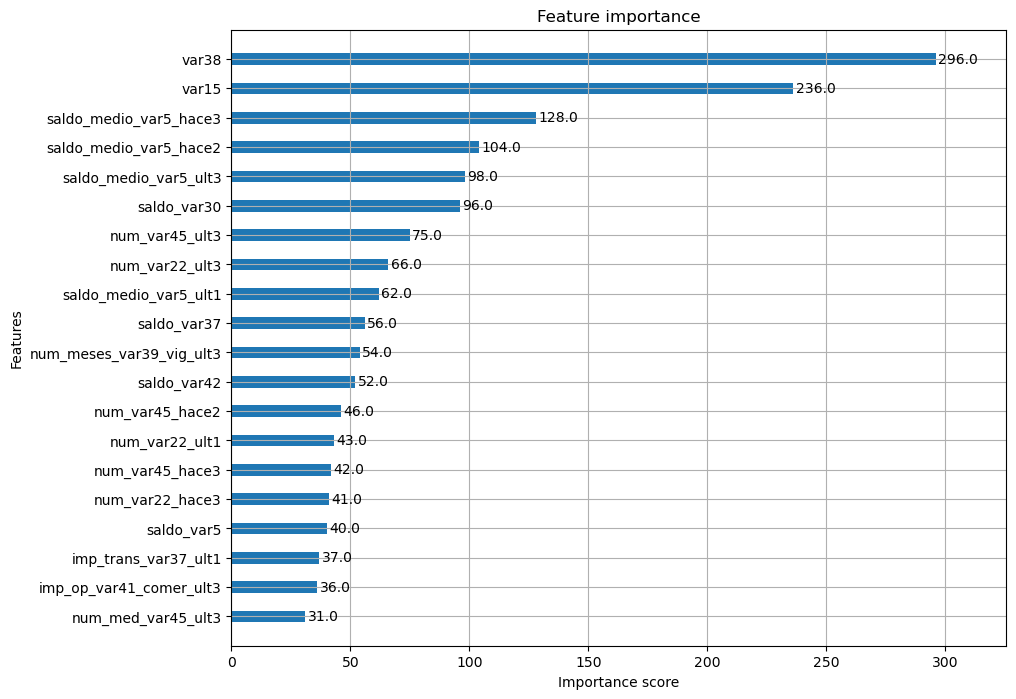

In [27]:
from xgboost import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig,ax=plt.subplots(1,1,figsize=(10,8))
plot_importance(xgb_clf,ax=ax,max_num_features=20,height=0.4)

LightGBM 모델 학습과 하이퍼 파라미터 튜닝

In [30]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.5 MB 2.4 MB/s eta 0:00:01
   ---------------------------- ----------- 1.0/1.5 MB 2.3 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 2.1 MB/s  0:00:00


In [31]:
from lightgbm import LGBMClassifier

lgbm_clf=LGBMClassifier(n_estimators=500, early_stopping_rounds=100)

eval_set=[(X_tr,y_tr),(X_val,y_val)]
lgbm_clf.fit(X_tr,y_tr,eval_set=eval_set, eval_metric="auc")

lgbm_roc_score=roc_auc_score(y_test,lgbm_clf.predict_proba(X_test)[:,1])
print('ROC AUC: {0:.4f}'.format(lgbm_roc_score))

[LightGBM] [Warning] early_stopping_round is set=100, early_stopping_rounds=100 will be ignored. Current value: early_stopping_round=100
[LightGBM] [Info] Number of positive: 1658, number of negative: 40913
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.184803 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 13308
[LightGBM] [Info] Number of data points in the train set: 42571, number of used features: 242
[LightGBM] [Warning] early_stopping_round is set=100, early_stopping_rounds=100 will be ignored. Current value: early_stopping_round=100
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.038947 -> initscore=-3.205836
[LightGBM] [Info] Start training from score -3.205836
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[42]	training's auc: 0.91059	training's binary_logloss: 0.112183	valid

In [32]:
lgbm_search_space={'num_leaves':hp.quniform('num_leaves',32,64,1),
                   'max_depth':hp.quniform('max_depth',100,160,1),
                   'min_child_samples':hp.quniform('min_child_samples',60,100,1),
                   'subsample':hp.uniform('subsample',0.7,1),
                   'learning_rate':hp.uniform('learning_rate',0.01,0.2)}

In [33]:
def objective_func(search_space):
    lgbm_clf = LGBMClassifier(n_estimators=500, 
                              num_leaves=int(search_space['num_leaves']),
                              max_depth=int(search_space['max_depth']),
                              min_child_samples=int(search_space['min_child_samples']),
                              subsample=search_space['subsample'],
                              learning_rate=search_space['learning_rate'],
                              early_stopping_round=30)
    
    # 3개 k-fold 방식으로 평가된 roc_auc 지표를 담는 list
    roc_auc_list=[]

    # 3개 k-fold 방식 적용
    kf=KFold(n_splits=3)
    # X_train을 다시 학습과 검증용 데이터로 분리
    for tr_index,val_index in kf.split(X_train):
        # kf.split(X_train)으로 추출된 학습과 검증 index 값으로 학습과 검증 데이터 세트 분리
        X_tr,y_tr=X_train.iloc[tr_index],y_train.iloc[tr_index]
        X_val,y_val=X_train.iloc[val_index],y_train.iloc[val_index]

        # early stopping은 30회로 설정하고 추출된 학습과 검증 데이터로 LGBMClassifier 학습 수행
        lgbm_clf.fit(X_tr,y_tr,eval_set=[(X_tr,y_tr),(X_val,y_val)],eval_metric="auc")

        # 1로 예측한 확률값 추출 후 roc auc 계산하고 평균 roc auc 계산을 위해 list에 결괏값 담음
        score=roc_auc_score(y_val,lgbm_clf.predict_proba(X_val)[:,1])
        roc_auc_list.append(score)

    # 3개 k_fold로 계산된 roc_auc 값의 평균값을 반환하되,
    # HyperOpt는 목적함수의 최솟값을 위한 입력값을 찾으므로 -1을 곱한 뒤 반환
    return -1*np.mean(roc_auc_list)

In [ ]:
from hyperopt import fmin,tpe, Trials

trials=Trials()

#fmin() 함수를 호출 -> max_evals 지정된 횟수만큼 반복 후 목적함수의 최솟값을 가지는 최적 입력값 추출
best=fmin(fn=objective_func,
          space=lgbm_search_space,
          algo=tpe.suggest, # 베이지안 최적화 적용 알고리즘: 좋은 결과가 나온 파라미터 근처 탐색해서 제안
          max_evals=50, # 최대 반복 횟수 지정
          trials=trials,rstate=np.random.default_rng(seed=30)) # Trial 객체에 탐색 기록 저장

print('best:',best)

[LightGBM] [Info] Number of positive: 1579, number of negative: 38965
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.215823 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12827                    
[LightGBM] [Info] Number of data points in the train set: 40544, number of used features: 192
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.038945 -> initscore=-3.205872
[LightGBM] [Info] Start training from score -3.205872 
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:                    
[140]	training's auc: 0.899486	training's binary_logloss: 0.117504	valid_1's auc: 0.832472	valid_1's binary_logloss: 0.135474
[LightGBM] [Info] Number of positive: 1609, number of negative: 38935
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.395980 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if mem

In [ ]:
lgbm_clf=LGBMClassifier(n_estimators=500, num_leaves=int(best['num_leaves']),
                        max_depth=int(best['max_depth']),
                        min_child_samples=int(best['min_child_samples']),
                        subsample=round(best['subsample'],5),
                        learning_rate=round(best['learning_rate'],5),
                        early_stopping_round=100, 
                        eval_metric="auc")

# evaluation metric을 auc로, early stopping은 100으로 설정하고 학습 수행. 
lgbm_clf.fit(X_tr,y_tr,eval_set=[(X_tr,y_tr),(X_val,y_val)])

lgbm_roc_score=roc_auc_score(y_test,lgbm_clf.predict_proba(X_test)[:,1]) # roc_auc는 임곗값을 0에서 1까지 올려가며 그래프를 그려야하기 때문에 확률값이 필요
print('ROC AUC: {0:.4f}'.format(lgbm_roc_score))